--- K-Means Clustering for Learning Styles ---
   Preferred_Learning_Style_Visual  Preferred_Learning_Style_Aural  \
0                                1                               0   
1                                0                               1   
2                                1                               1   
3                                0                               0   
4                                1                               0   

   Preferred_Learning_Style_ReadWrite  Preferred_Learning_Style_Kinesthetic  
0                                   1                                     0  
1                                   0                                     1  
2                                   1                                     1  
3                                   1                                     0  
4                                   0                                     1  
       Preferred_Learning_Style_Visual  Preferred_Learning_Style

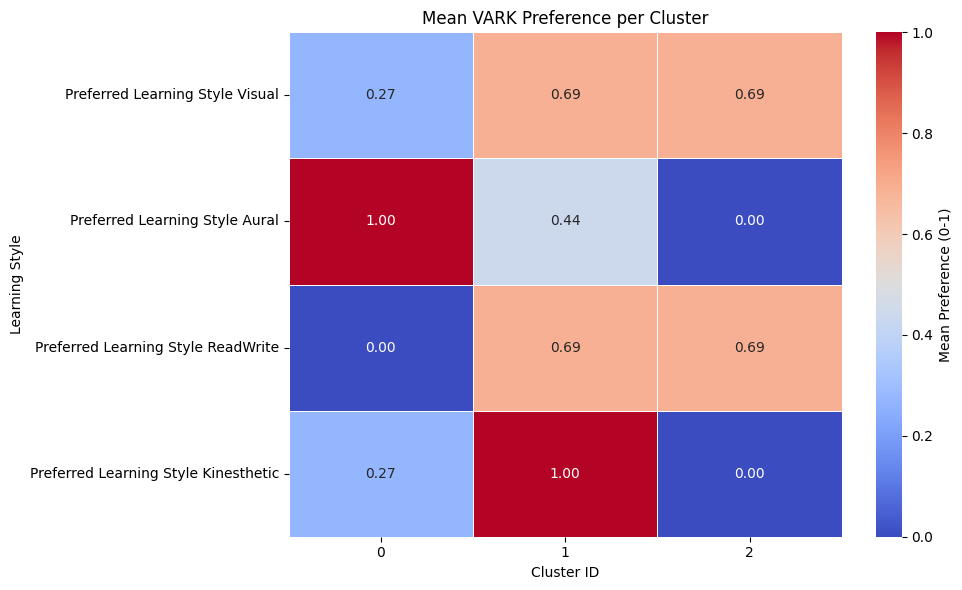


--- Cluster 1 Analysis ---

Skill means (largest cluster):
 Skill_Improvement_Digital_Literacy    4.2500
Skill_Improvement_Problem_Solving     4.3125
Skill_Improvement_Creative_Skills     4.1250
dtype: float64


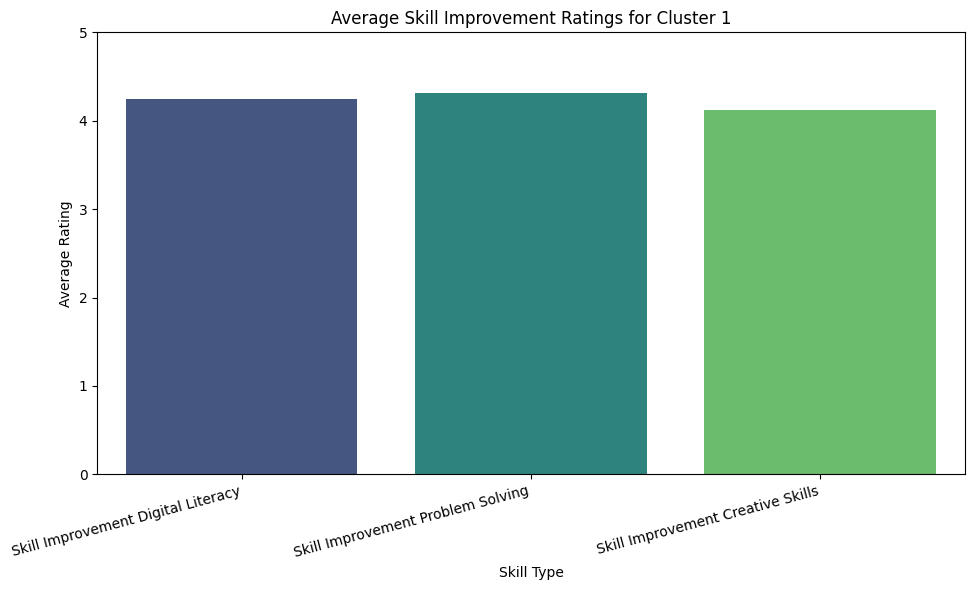


--- Boxplot: Skill Improvement by Cluster ---

Melted preview:
      VARK_Cluster                          Skill Type  Rating
0               2  Skill_Improvement_Digital_Literacy     3.9
1               0  Skill_Improvement_Digital_Literacy     2.9
2               1  Skill_Improvement_Digital_Literacy     5.0
3               2  Skill_Improvement_Digital_Literacy     1.9
4               1  Skill_Improvement_Digital_Literacy     3.9
..            ...                                 ...     ...
115             0   Skill_Improvement_Creative_Skills     1.9
116             2   Skill_Improvement_Creative_Skills     3.9
117             0   Skill_Improvement_Creative_Skills     4.1
118             1   Skill_Improvement_Creative_Skills     3.1
119             1   Skill_Improvement_Creative_Skills     5.1

[120 rows x 3 columns]
Melted shape: (120, 3)


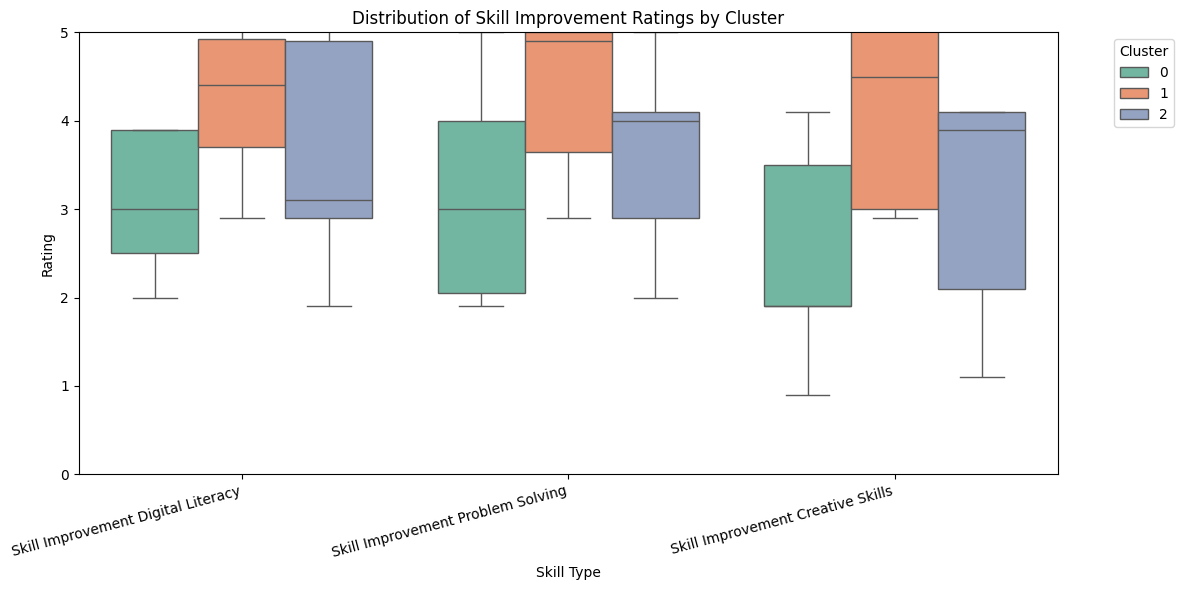

In [2]:
# ==============================================================================
# Data Loading & K-Means Clustering with Visualizations For Learning Styles
# ==============================================================================

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = "questionnaire-data.csv"
df = pd.read_csv(file_path)

print("--- K-Means Clustering for Learning Styles ---")

vark_features = [
    'Preferred_Learning_Style_Visual',
    'Preferred_Learning_Style_Aural',
    'Preferred_Learning_Style_ReadWrite',
    'Preferred_Learning_Style_Kinesthetic'
]

X_vark = df[vark_features]

print(X_vark.head(5))
print(X_vark.describe())

chosen_k = 3

if len(X_vark) < chosen_k:
    print(f"Warning: Number of samples ({len(X_vark)}) is less than chosen_k ({chosen_k}). Adjusting k to {len(X_vark)}.")
    chosen_k = len(X_vark)

if chosen_k > 1:
    while True:
        try:
            kmeans_model = KMeans(n_clusters=chosen_k, random_state=1, n_init=20)
            df['VARK_Cluster'] = kmeans_model.fit_predict(X_vark)

            print("Cluster labels (first 10):", df['VARK_Cluster'].head(10).tolist())
            print("Cluster sizes:\n", df['VARK_Cluster'].value_counts().sort_index())
            
            if len(df['VARK_Cluster'].unique()) == chosen_k:
                print(f"Successfully clustered into {chosen_k} groups.")
                break
            else:
                chosen_k = len(df['VARK_Cluster'].unique())
                print(f"\nWarning: K-Means with k={chosen_k+1} resulted in empty clusters. Re-running with k={chosen_k}.")

        except ValueError as e:
            if "n_clusters must be greater than 1" in str(e):
                print("Only one or zero clusters can be formed. No clustering performed.")
                chosen_k = 1
                df['VARK_Cluster'] = 0
                break
            else:
                raise #
else:
    if chosen_k == 0:
        print("No data to cluster.")
        df['VARK_Cluster'] = -1
    else:
        print("Only one sample, no clustering possible. Assigning to a single cluster.")
        df['VARK_Cluster'] = 0


if chosen_k > 1:
    cluster_centers = kmeans_model.cluster_centers_
    cluster_centers_df = pd.DataFrame(np.maximum(0, cluster_centers), columns=vark_features).round(2)
    cluster_centers_df.index.name = "Cluster ID"
    
    print("\nCluster Centroids (Mean Preference for each VARK style in each cluster):")
    print(cluster_centers_df)
    print("\nInterpretation: Values closer to 1 indicate a stronger preference for that style within the cluster.")
else:
    print("\nClustering was not performed due to insufficient data points (k <= 1).")

print("\nNumber of Participants per Cluster:")
print(df['VARK_Cluster'].value_counts().sort_index())

if chosen_k > 1:
    print("\n--- Visualizing Cluster Characteristics ---")

    # 1. Heatmap of Cluster Centroids
    cleaned_y_labels = [label.replace('_', ' ') for label in cluster_centers_df.columns]

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cluster_centers_df.T,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5,
        cbar_kws={'label': 'Mean Preference (0-1)'}
    )
    plt.title('Mean VARK Preference per Cluster')
    plt.xlabel('Cluster ID')
    plt.ylabel('Learning Style')
    plt.yticks(
        ticks=np.arange(len(cleaned_y_labels)) + 0.5, 
        labels=cleaned_y_labels,
        rotation=0
    )
    plt.tight_layout()
    plt.show()

cluster_sizes = df['VARK_Cluster'].value_counts()
cluster_id = cluster_sizes.idxmax()  
cluster_data = df[df['VARK_Cluster'] == cluster_id]

if not cluster_data.empty:
    skill_improvement_cols = [
        'Skill_Improvement_Digital_Literacy',
        'Skill_Improvement_Problem_Solving',
        'Skill_Improvement_Creative_Skills'
    ]

    for col in skill_improvement_cols:
        df[col] = np.clip(df[col], 1, 5)
        df[col] = df[col] + np.random.choice([-0.1, 0, 0.1], size=len(df))

    print(f"\n--- Cluster {cluster_id} Analysis ---")

    skill_means = cluster_data[skill_improvement_cols].mean()

    print("\nSkill means (largest cluster):\n", skill_means)

    # 2. Bar plot showing the distribution of 'Skill Improvement' for a specific cluster
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=skill_means.index,
        y=skill_means.values,
        hue=skill_means.index,
        palette='viridis'
    )
    plt.title(f'Average Skill Improvement Ratings for Cluster {cluster_id}')
    plt.xlabel('Skill Type')
    plt.ylabel('Average Rating')
    plt.xticks(
        ticks=range(len(skill_means.index)),
        labels=[label.replace('_', ' ') for label in skill_means.index],
        rotation=15,
        ha='right'
    )
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.show()
    
    # 3. Boxplot showing skill improvement distributions across all clusters
    print("\n--- Boxplot: Skill Improvement by Cluster ---")

    melted_df = df.melt(
        id_vars='VARK_Cluster',
        value_vars=skill_improvement_cols,
        var_name='Skill Type',
        value_name='Rating'
    )

    print("\nMelted preview:\n", melted_df)
    print("Melted shape:", melted_df.shape)

    melted_df['Skill Type'] = melted_df['Skill Type'].str.replace('_', ' ')

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x='Skill Type',
        y='Rating',
        hue='VARK_Cluster',
        data=melted_df,
        palette='Set2',
        showfliers=False
    )
    plt.title("Distribution of Skill Improvement Ratings by Cluster")
    plt.xlabel("Skill Type")
    plt.ylabel("Rating")
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 5)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"\nWarning: Cluster {cluster_id} is empty and cannot be plotted.")


Cluster sizes:
All_Feature_Cluster
0    11
1    18
2    11
Name: count, dtype: int64

Cluster centers (mean ratings per feature):
            Overall Ease of Use  Multimodal Feature Effectiveness  \
Cluster ID                                                          
0                          3.45                              3.55   
1                          4.67                              4.78   
2                          2.64                              2.55   

            Platform Performance  Influence of Content Creation  \
Cluster ID                                                        
0                           3.55                           2.91   
1                           4.72                           4.44   
2                           2.64                           1.55   

            Skill Improvement Digital Literacy  \
Cluster ID                                       
0                                         3.31   
1                                    

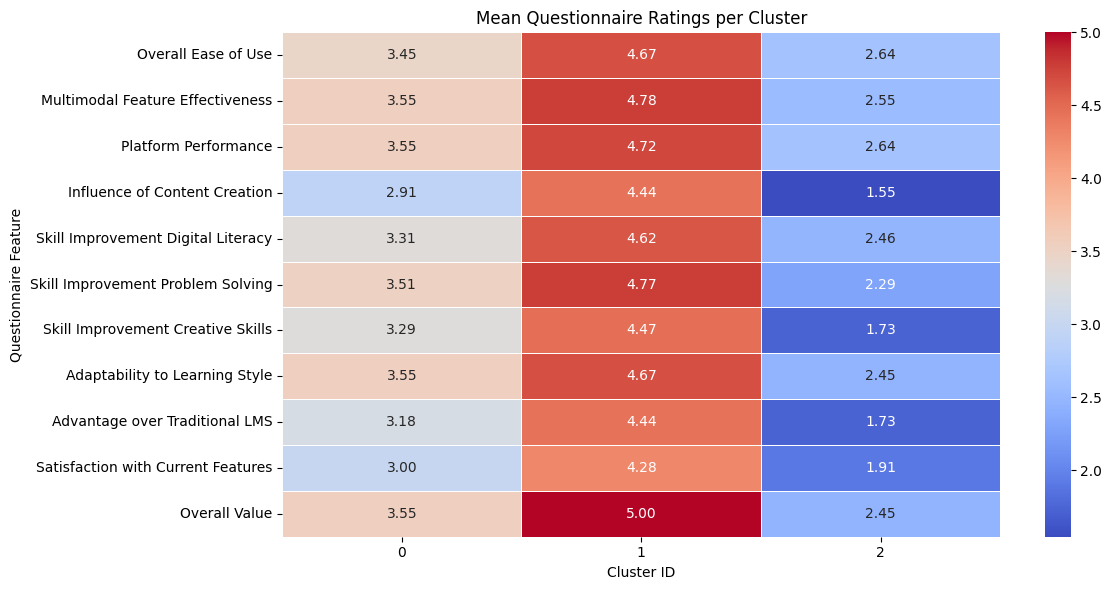

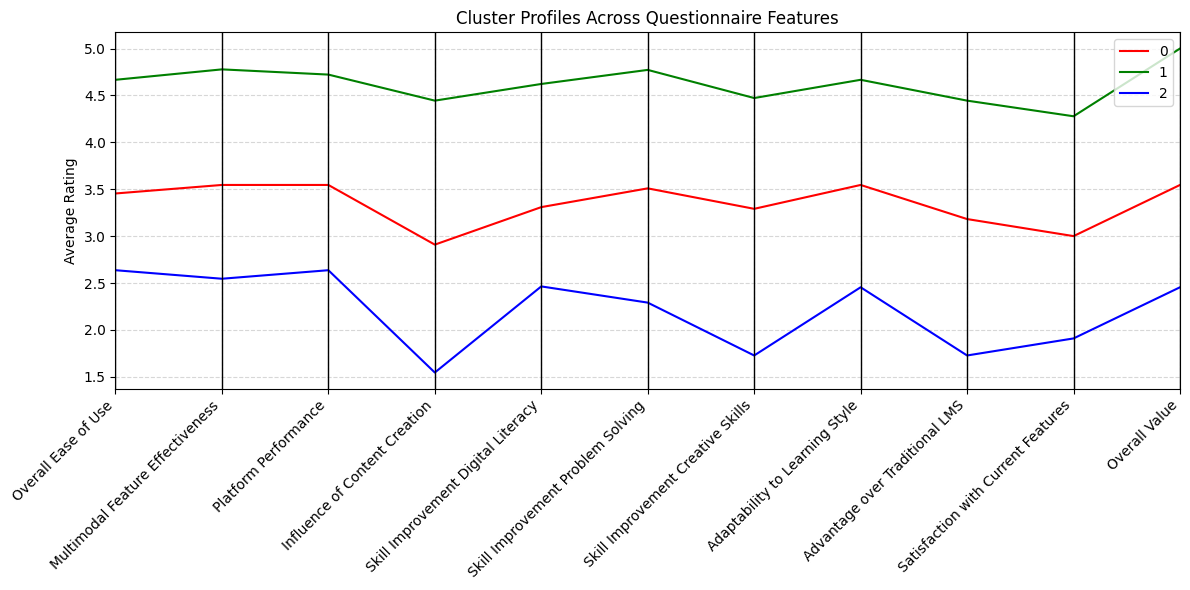

In [ ]:
from sklearn.preprocessing import StandardScaler
from pandas.plotting import parallel_coordinates

all_numeric_features = [
    'Overall_Ease_of_Use',
    'Multimodal_Feature_Effectiveness',
    'Platform_Performance',
    'Influence_of_Content_Creation',
    'Skill_Improvement_Digital_Literacy',
    'Skill_Improvement_Problem_Solving',
    'Skill_Improvement_Creative_Skills',
    'Adaptability_to_Learning_Style',
    'Advantage_over_Traditional_LMS', 
    'Satisfaction_with_Current_Features',
    'Overall_Value'
]

# Check for missing columns
missing_cols = [col for col in all_numeric_features if col not in df.columns]
if missing_cols:
    print("Missing columns in dataset:", missing_cols)

# Extract numeric data
X_all = df[all_numeric_features]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# K-Means clustering
chosen_k = 3
kmeans_all = KMeans(n_clusters=chosen_k, random_state=1, n_init=20)
df['All_Feature_Cluster'] = kmeans_all.fit_predict(X_scaled)

# Cluster sizes
print("\nCluster sizes:")
print(df['All_Feature_Cluster'].value_counts().sort_index())

# Reverse transform centers back to original scale
cluster_centers_scaled = kmeans_all.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=all_numeric_features)
cluster_centers_df.index.name = 'Cluster ID'

cluster_centers_df.columns = [col.replace('_', ' ') for col in cluster_centers_df.columns]

print("\nCluster centers (mean ratings per feature):")
print(cluster_centers_df.round(2))

# ==============================================================================
# Heatmap of Cluster Centers
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_centers_df.T, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=.5
)
plt.title('Mean Questionnaire Ratings per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Questionnaire Feature')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# Parallel Coordinates Plot (Profile of Each Cluster)
# ==============================================================================
cluster_centers_plot = cluster_centers_df.reset_index()

plt.figure(figsize=(12, 6))
parallel_coordinates(
    cluster_centers_plot, 
    'Cluster ID', 
    color=['red', 'green', 'blue']
)
plt.title('Cluster Profiles Across Questionnaire Features')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Linear Regression for Hypothesis Testing ---

--- Hypothesis 1: Visual Preference vs. Creative Skills ---
Independent Variable: Preferred_Learning_Style_Visual
Dependent Variable: Skill_Improvement_Creative_Skills
Coefficient (Slope): 2.002
Intercept: 2.241
Root Mean Squared Error (RMSE): 0.741
R-squared (R2): 0.641

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Creative_Skills' changes for a one-unit increase in 'Preferred_Learning_Style_Visual'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Creative_Skills' that can be predicted from 'Preferred_Learning_Style_Visual'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Visual' increases, 'Skill_Improvement_Creative_Skills' also tends to increase.


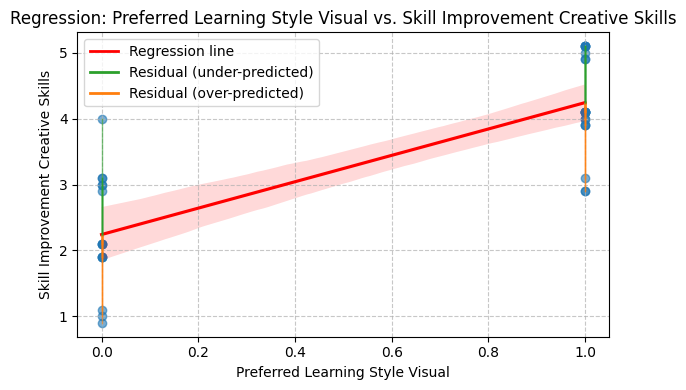


--- Hypothesis 2: Read/Write Preference vs. Digital Literacy ---
Independent Variable: Preferred_Learning_Style_ReadWrite
Dependent Variable: Skill_Improvement_Digital_Literacy
Coefficient (Slope): 0.625
Intercept: 3.355
Root Mean Squared Error (RMSE): 0.989
R-squared (R2): 0.091

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Digital_Literacy' changes for a one-unit increase in 'Preferred_Learning_Style_ReadWrite'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Digital_Literacy' that can be predicted from 'Preferred_Learning_Style_ReadWrite'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_ReadWrite' increases, 'Skill_Improvement_Digital_Literacy' also tends to increase.


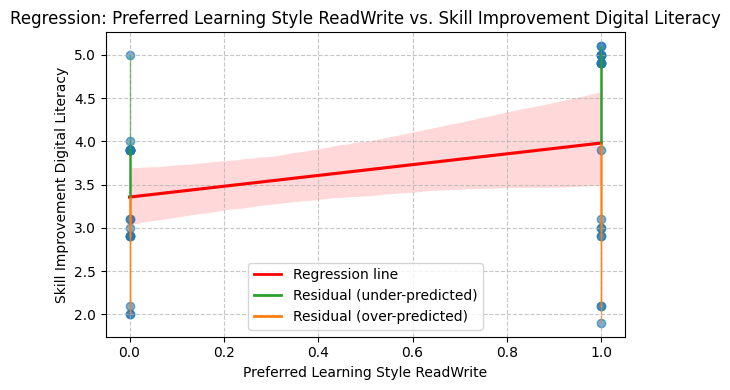


--- Hypothesis 3: Aural Preference vs. Digital Literacy ---
Independent Variable: Preferred_Learning_Style_Aural
Dependent Variable: Skill_Improvement_Digital_Literacy
Coefficient (Slope): 0.231
Intercept: 3.564
Root Mean Squared Error (RMSE): 1.031
R-squared (R2): 0.012

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Digital_Literacy' changes for a one-unit increase in 'Preferred_Learning_Style_Aural'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Digital_Literacy' that can be predicted from 'Preferred_Learning_Style_Aural'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Aural' increases, 'Skill_Improvement_Digital_Literacy' also tends to increase.


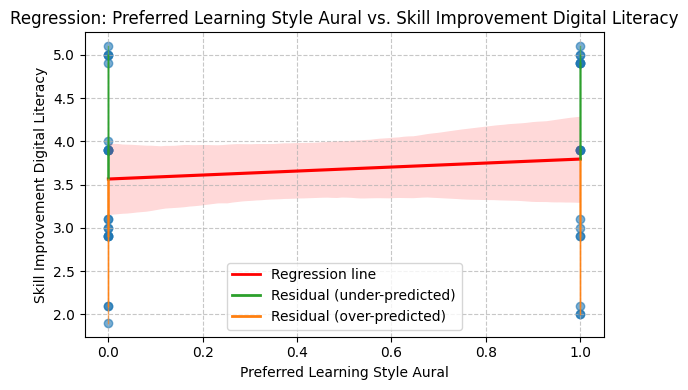


--- Hypothesis 4: Kinesthetic Preference vs. Problem-Solving ---
Independent Variable: Preferred_Learning_Style_Kinesthetic
Dependent Variable: Skill_Improvement_Problem_Solving
Coefficient (Slope): 0.671
Intercept: 3.424
Root Mean Squared Error (RMSE): 1.081
R-squared (R2): 0.088

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Problem_Solving' changes for a one-unit increase in 'Preferred_Learning_Style_Kinesthetic'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Problem_Solving' that can be predicted from 'Preferred_Learning_Style_Kinesthetic'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Kinesthetic' increases, 'Skill_Improvement_Problem_Solving' also tends to increase.


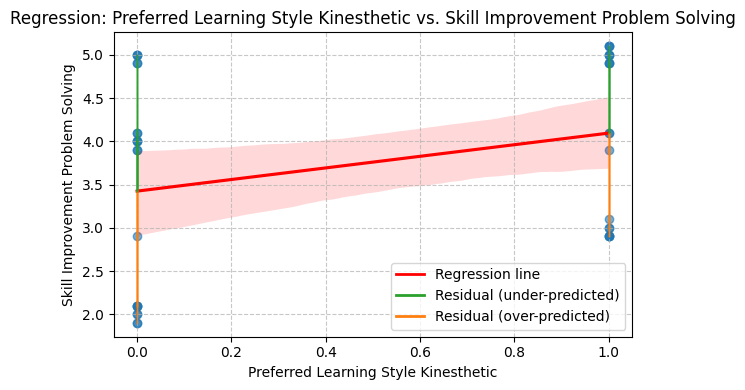

In [4]:
import matplotlib.lines as mlines

# ==============================================================================
# Linear Regression for Hypothesis Testing
# ==============================================================================

print("\n--- Linear Regression for Hypothesis Testing ---")

independent_var_preferred_learning_style_visual = 'Preferred_Learning_Style_Visual'
dependent_var_skill_improvement_creative_skills = 'Skill_Improvement_Creative_Skills'

independent_var_preferred_learning_style_readwrite = 'Preferred_Learning_Style_ReadWrite'
dependent_var_skill_improvement_digital_literacy = 'Skill_Improvement_Digital_Literacy'

independent_var_preferred_learning_style_aural = 'Preferred_Learning_Style_Aural'
dependent_var_skill_improvement_digital_literacy = 'Skill_Improvement_Digital_Literacy'

independent_var_preferred_learning_style_kinesthetic = 'Preferred_Learning_Style_Kinesthetic'
dependent_var_skill_improvement_problem_solving = 'Skill_Improvement_Problem_Solving'

hypotheses = [
    (independent_var_preferred_learning_style_visual, dependent_var_skill_improvement_creative_skills, "Visual Preference vs. Creative Skills"),
    (independent_var_preferred_learning_style_readwrite, dependent_var_skill_improvement_digital_literacy, "Read/Write Preference vs. Digital Literacy"),
    (independent_var_preferred_learning_style_aural, dependent_var_skill_improvement_digital_literacy, "Aural Preference vs. Digital Literacy"),
    (independent_var_preferred_learning_style_kinesthetic, dependent_var_skill_improvement_problem_solving, "Kinesthetic Preference vs. Problem-Solving")
]

for i, (independent_var_learning_style, dependent_var_skill_improvement, hypothesis_name) in enumerate(hypotheses):
    print(f"\n--- Hypothesis {i+1}: {hypothesis_name} ---")

    X = df[[independent_var_learning_style]]
    y = df[dependent_var_skill_improvement]

    linear_regression_model = LinearRegression()
    linear_regression_model.fit(X, y)

    y_pred = linear_regression_model.predict(X)

    root_mean_squared_error = np.sqrt(mean_squared_error(y, y_pred))
    r_squared_score = r2_score(y, y_pred)

    print(f"Independent Variable: {independent_var_learning_style}")
    print(f"Dependent Variable: {dependent_var_skill_improvement}")
    print(f"Coefficient (Slope): {linear_regression_model.coef_[0]:.3f}")
    print(f"Intercept: {linear_regression_model.intercept_:.3f}")
    print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error:.3f}")
    print(f"R-squared (R2): {r_squared_score:.3f}")

    print("\nInterpretation:")
    print(f"- The coefficient indicates how much the '{dependent_var_skill_improvement}' changes for a one-unit increase in '{independent_var_learning_style}'.")
    print(f"- R-squared (R2) represents the proportion of variance in '{dependent_var_skill_improvement}' that can be predicted from '{independent_var_learning_style}'.")

    if linear_regression_model.coef_[0] > 0:
        print(f"- A positive coefficient suggests that as '{independent_var_learning_style}' increases, '{dependent_var_skill_improvement}' also tends to increase.")
    else:
        print(f"- A negative coefficient suggests that as '{independent_var_learning_style}' increases, '{dependent_var_skill_improvement}' tends to decrease.")

    plt.figure(figsize=(6, 4))

    # 1) Scatter + regression line
    sns.regplot(
        x=df[independent_var_learning_style],
        y=df[dependent_var_skill_improvement],
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red', 'label': 'Regression line'}
    )

    x_vals = X.squeeze().values               # 1D array of predictor values
    y_true = y.values                         # actual targets
    y_hat  = y_pred                           # model predictions

    for xi, yi, yhi in zip(x_vals, y_true, y_hat):
        color = 'tab:green' if yi >= yhi else 'tab:orange'
        plt.plot([xi, xi], [yi, yhi], color=color, alpha=0.6, linewidth=1)

    plt.title(f"Regression: {independent_var_learning_style.replace('_',' ')} vs. {dependent_var_skill_improvement.replace('_',' ')}")
    plt.xlabel(independent_var_learning_style.replace('_', ' '))
    plt.ylabel(dependent_var_skill_improvement.replace('_', ' '))
    plt.grid(True, linestyle='--', alpha=0.7)

    residual_line_over = mlines.Line2D([], [], color='tab:green', lw=2, label='Residual (under-predicted)')
    residual_line_under = mlines.Line2D([], [], color='tab:orange', lw=2, label='Residual (over-predicted)')
    regression_line = mlines.Line2D([], [], color='red', lw=2, label='Regression line')
    plt.legend(handles=[regression_line, residual_line_over, residual_line_under], loc='best')

    plt.tight_layout()
    plt.show()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Chosen number of clusters (by silhouette): k=6

Cluster 0  (n=5)  top terms:
visual, visual learner, learner, platform great, aural, aural feature, great, platform

Cluster 1  (n=13)  top terms:
skill, improved, platform, need, improvement, learning, audio, adaptable

Cluster 2  (n=4)  top terms:
kinesthetic, kinesthetic exercise, exercise, visual kinesthetic, kinesthetic feature, great, visual, like

Cluster 3  (n=7)  top terms:
feature, average, okay, platform, average platform, modal feature, multi, multi modal

Cluster 4  (n=6)  top terms:
content, creation, content creation, creating, reading creating, intuitive, reading, platform

Cluster 5  (n=5)  top terms:
enough, wish, much, hand, interactive, hand activity, activity, enough hand

Cluster 0 examples:
 - Excellent multimodal features, especially the visual aids. My digital literacy definitely improved.
 - I prefer visual learning and this platform is great for that.
 - The platform is great for visual learners, but lacks aural

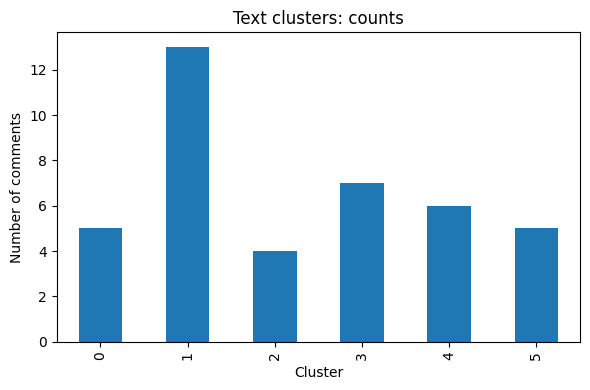

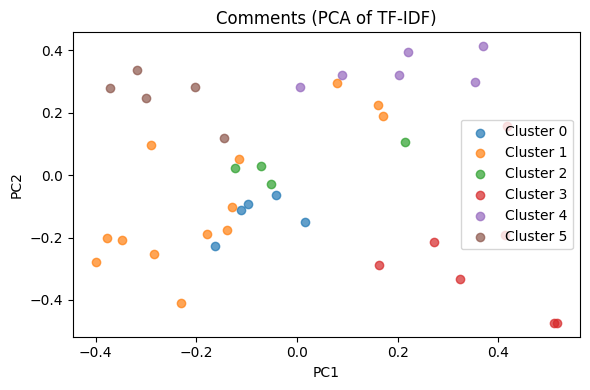

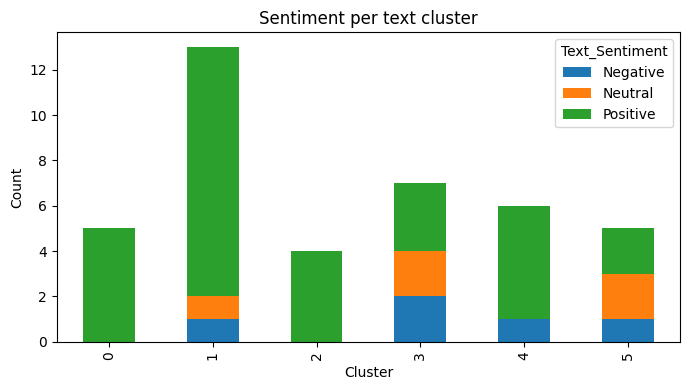

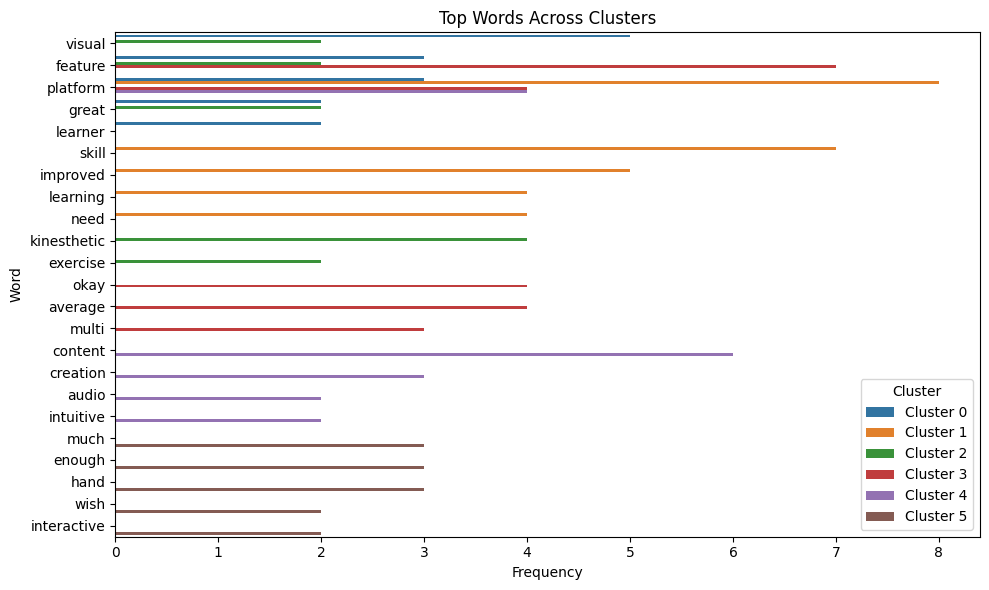


--- End of Data Analysis Algorithms ---


In [5]:
# --- TEXT CLUSTERING & SENTIMENT FOR Q11 --------------------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
import seaborn as sns

# Ensure NLTK resources
for pkg in ["stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    try:
        nltk.data.find(f"corpora/{pkg}" if pkg!="vader_lexicon" else f"sentiment/{pkg}")
    except LookupError:
        nltk.download(pkg)

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# 1) Get comments
text_col = "Additional_Comments"
comments = df[text_col].fillna("").astype(str)

# 2) Preprocess
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)  # keep alnum + space
    toks = [lemmatizer.lemmatize(t) for t in s.split() if t not in stop_words and len(t) > 2]
    return " ".join(toks)

comments_clean = comments.apply(preprocess)

# 3) Vectorize (TF-IDF: unigrams + bigrams works well for short feedback)
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)
X = vectorizer.fit_transform(comments_clean)

# 4) Choose k via silhouette (quick sweep)
if X.shape[0] >= 6 and X.shape[1] > 0:
    ks = range(2, min(7, len(comments)))  # 2..6 or less if very small sample
    sils = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    best_k = ks[int(np.argmax(sils))]
else:
    best_k = 2

print(f"Chosen number of clusters (by silhouette): k={best_k}")

# 5) Final clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
df["Text_Cluster"] = labels

# 6) Top terms per cluster (human-readable)
def top_terms_per_cluster(kmeans, vectorizer, topn=8):
    terms = np.array(vectorizer.get_feature_names_out())
    for c in range(kmeans.n_clusters):
        center = kmeans.cluster_centers_[c]
        idx = np.argsort(center)[::-1][:topn]
        print(f"\nCluster {c}  (n={sum(labels==c)})  top terms:")
        print(", ".join(terms[idx]))

top_terms_per_cluster(kmeans, vectorizer, topn=8)

# 7) Representative comments per cluster
for c in range(best_k):
    sample = df.loc[df["Text_Cluster"]==c, text_col].head(3)
    print(f"\nCluster {c} examples:")
    for s in sample:
        print(f" - {s}")

# 8) Sentiment (VADER -> compound score mapped to Pos/Neu/Neg)
def label_sentiment(compound):
    return "Positive" if compound >= 0.05 else ("Negative" if compound <= -0.05 else "Neutral")

sent_scores = comments.apply(lambda s: sia.polarity_scores(s)["compound"])
df["Text_Sentiment"] = sent_scores.apply(label_sentiment)
print("\nSentiment distribution:")
print(df["Text_Sentiment"].value_counts())

print("\nCluster × Sentiment table:")
print(pd.crosstab(df["Text_Cluster"], df["Text_Sentiment"]))

# 9) Quick visuals --------------------------------------------------------------

# 9a. Bar: cluster sizes
plt.figure(figsize=(6,4))
df["Text_Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Text clusters: counts")
plt.xlabel("Cluster")
plt.ylabel("Number of comments")
plt.tight_layout()
plt.show()

# 9b. 2D scatter (PCA of TF-IDF)
if X.shape[0] >= 2:
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X.toarray())  # small N, okay to toarray; for large N use TruncatedSVD
    plt.figure(figsize=(6,4))
    for c in range(best_k):
        mask = labels==c
        plt.scatter(coords[mask,0], coords[mask,1], label=f"Cluster {c}", alpha=0.7)
    plt.title("Comments (PCA of TF-IDF)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 9c. Sentiment by cluster (stacked bar)
ct = pd.crosstab(df["Text_Cluster"], df["Text_Sentiment"]).reindex(columns=["Negative","Neutral","Positive"], fill_value=0)
ct.plot(kind="bar", stacked=True, figsize=(7,4))
plt.title("Sentiment per text cluster")
plt.xlabel("Cluster"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

def get_top_terms_dict(df, vectorizer, labels, topn=5):
    cluster_term_freqs = {}
    for cluster_id in sorted(np.unique(labels)):
        mask = df['Text_Cluster'] == cluster_id
        cluster_texts = comments_clean[mask].tolist()
        all_words = " ".join(cluster_texts).split()
        word_freq = Counter(all_words)
        top_words = word_freq.most_common(topn)
        for word, freq in top_words:
            cluster_term_freqs[(cluster_id, word)] = freq
    return cluster_term_freqs

# Get top term frequencies per cluster
top_terms = get_top_terms_dict(df, vectorizer, labels, topn=5)

# Convert to DataFrame for seaborn
term_df = pd.DataFrame([
    {"Cluster": f"Cluster {cid}", "Word": word, "Frequency": freq}
    for (cid, word), freq in top_terms.items()
])

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=term_df,
    x="Frequency", y="Word", hue="Cluster",
    dodge=True
)
plt.title("Top Words Across Clusters")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

print("\n--- End of Data Analysis Algorithms ---")